In [1]:
from kan import KAN, create_dataset
import torch

from torch import nn
from torch.nn import functional as F
from torch import optim
import numpy as np
import math
import os
import argparse

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import matplotlib.pyplot as plt

In [2]:

def readfile(filename):
    try:
        f = open(filename)
        out = f.readlines()
        f.close()
    except IOError:
        print('File %s does not exist!' % (filename))
        sys.exit(12)
    return out


# In[16]:


def writefile(filename, content):
    # content can be either a string or a list of strings
    try:
        f = open(filename, 'w')
        if isinstance(content, list):
            for line in content:
                f.write(line)
        elif isinstance(content, str):
            f.write(content)
        else:
            print('Content %s cannot be written to file!' % (content))
            sys.exit(13)
        f.close()
    except IOError:
        print('Could not write to file %s!' % (filename))
        sys.exit(14)
        
        
def eformat(f, prec, exp_digits):
    '''Formats a float f into scientific notation with prec number of decimals and exp_digits number of exponent digits.

    String looks like:
    [ -][0-9]\\.[0-9]*E[+-][0-9]*

    Arguments:
    1 float: Number to format
    2 integer: Number of decimals
    3 integer: Number of exponent digits

    Returns:
    1 string: formatted number'''

    s = "% .*e" % (prec, f)
    mantissa, exp = s.split('e')
    return "%sE%+0*d" % (mantissa, exp_digits + 1, int(exp))


# In[17]:


def itmult(states):

    for i in range(len(states)):
        if states[i] < 1:
            continue
        yield i + 1
    return

# ======================================================================= #


def itnmstates(states):

    for i in range(len(states)):
        if states[i] < 1:
            continue
        for k in range(i + 1):
            for j in range(states[i]):
                yield i + 1, j + 1, k - i / 2.
    return


# In[18]:
Natoms = 8

states = [2,0,2]
sum_muti = sum(states) ## mutistate number 

nstates = 0
for imult, i, ims in itnmstates(states):
    print(imult, i, ims)
    nstates += 1
    
nstates  ## substates number


# In[19]:


qmout = readfile('../Hflow_data/QM_0.out')


1 1 0.0
1 2 0.0
3 1 -1.0
3 2 -1.0
3 1 0.0
3 2 0.0
3 1 1.0
3 2 1.0


In [3]:
## calc the T for step_lines

apd = np.int64(np.array([]))
for iline, line in enumerate(qmout):
    if "Step" in line:
        apd = np.append(apd, iline)
        
line_T = apd[1]-apd[0]

In [4]:
Natoms = 8

In [5]:
cut_step = 1001

    
def getdata_fromQMout(qmout,cut_step):
    E = np.zeros([cut_step, sum_muti])
    X = np.zeros([cut_step, Natoms, 3])
    G = np.zeros([cut_step, sum_muti, Natoms, 3])
    SOC_R = np.zeros([cut_step, nstates, nstates])
    SOC_I = np.zeros([cut_step, nstates, nstates])
    H_MCH = np.complex128(np.zeros([cut_step, nstates, nstates]))
    Ovlps = np.zeros([cut_step,nstates,nstates])
    
    kk = 0
    for iline, line in enumerate(qmout):
        if "Step" in line:
            if int(qmout[iline+1]) >= cut_step:
                break
                
            else:
                for jcheck in range(line_T):
                    
                    if "Hamiltonian" in qmout[iline+jcheck]:
                        for j in range(sum_muti):
                            E[kk,j] = float(qmout[iline + jcheck + 1 + j].split()[2*j])
                        
                        ## get socs data
                        for I in range(nstates):
                            for J in range(nstates):
                                ## get all MCH Hamiltonian elements (complex)
                                H_MCH[kk,I,J] = float(qmout[iline+jcheck+1+I].split()[2*J]) + float(qmout[iline+jcheck+1+I].split()[2*J+1])*1j
                                
                                ## get only socs data
                                if I!=J:
                                    SOC_R[kk,I,J] = float(qmout[iline + jcheck + 1 + I].split()[2*J])
                                    SOC_I[kk,I,J] = float(qmout[iline + jcheck + 1 + I].split()[2*J+1])
                    
                        break
                        
                        
    
                for jcheck in range(line_T):
                    
                    if "Geometry" in qmout[iline+jcheck]:
                        for iatom in range(Natoms):
                            for ixyz in range(3):
                                X[kk, iatom, ixyz] = float(qmout[iline+jcheck+1+iatom].split()[ixyz])
                    
                        break
                        
                for jcheck in range(line_T):
                    for s in range(sum_muti):
                        
                        if f"Gradients (MCH) State  {s+1}" in qmout[iline+jcheck]:
                            for iatom in range(Natoms):
                                for ixyz in range(3):
                                    G[kk, s, iatom, ixyz] = float(qmout[iline+jcheck+1+iatom].split()[ixyz])
                                    
                            break
                            
    ################################################################
                for jcheck in range(line_T):
                    
                    if "Overlap" in qmout[iline+jcheck]:
                        for i in range(nstates):
                            for j in range(nstates):
                                Ovlps[kk, i, j] = qmout[iline+jcheck+1+i].split()[2*j]
                            
                        
                        break
    ################################################################
    
            kk+=1
        
    return E, X, G, SOC_R, SOC_I, H_MCH, X[:-1], X[1:], Ovlps[1:] ##

In [6]:

def cross_mutip(a,b):

    T1=torch.transpose(torch.tensor([[[0., 1. ,0.],[0., 0., 1.],[1., 0., 0.]]]),1,2).to(device)
    T2=torch.transpose(torch.tensor([[[0., 0., 1.],[1., 0., 0.],[0., 1., 0.]]]),1,2).to(device)
    
    return torch.matmul(a,T1)*torch.matmul(b,T2) - torch.matmul(a,T2)*torch.matmul(b,T1)


def Internal_to_XYZ(Internal_all):

    N_dih = toplist.shape[0]
    
    ##@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    N_batch = Internal_all.shape[0]
    b10 = Internal_all[:,:,0:1]
    b12= Internal_all[:,:,1:2]
    a012 = Internal_all[:,:,2:3]
    
    Translate = Internal_all[:,:,-3:]  ## bohr
    
    bond_list = Internal_all[:,:,3:3+N_dih]
    angle_list = Internal_all[:,:,3+N_dih:3+2*N_dih]
    dih_list = Internal_all[:,:,3+2*N_dih:3+3*N_dih]
    ##@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    
    Rotate_θ = Internal_all[:,:,-6:-5]  ### θ φ β (rad) 
    Rotate_φ = Internal_all[:,:,-5:-4]
    Rotate_β = Internal_all[:,:,-4:-3]
    
    R_z = torch.cos(Rotate_θ)*torch.tensor([[1.,0.,0.],
                                          [0.,1.,0.],
                                          [0.,0.,0.]]).to(device) + \
    torch.sin(Rotate_θ)*torch.tensor([[0.,1.,0.],
                                     [-1.,0.,0.],
                                     [0.,0.,0.]]).to(device) + \
    torch.tensor([[0.,0.,0.],
                 [0.,0.,0.,],
                 [0.,0.,1.]]).to(device)
    
    
    R_y = torch.cos(Rotate_φ)*torch.tensor([[1.,0.,0.],
                                          [0.,0.,0.],
                                          [0.,0.,1.]]).to(device) + \
    torch.sin(Rotate_φ)*torch.tensor([[0.,0.,1.],
                                     [0.,0.,0.],
                                     [-1.,0.,0.]]).to(device) + \
    torch.tensor([[0.,0.,0.],
                 [0.,1.,0.,],
                 [0.,0.,0.]]).to(device)
    
    R_x = torch.cos(Rotate_β)*torch.tensor([[0.,0.,0.],
                                          [0.,1.,0.],
                                          [0.,0.,1.]]).to(device) + \
    torch.sin(Rotate_β)*torch.tensor([[0.,0.,0.],
                                     [0.,0.,1.],
                                     [0.,-1.,0.]]).to(device) + \
    torch.tensor([[1.,0.,0.],
                 [0.,0.,0.,],
                 [0.,0.,0.]]).to(device)
    
    #torch.matmul(torch.matmul(torch.matmul(A_i_,R_x),R_y),R_z)
    
    ##@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    
    xyzall = torch.zeros([N_batch,Natoms,3]).to(device)
    
    A_j_ = torch.zeros([N_batch,1,3]).to(device)
    A_k_ = torch.tensor([[1.,0.,0.]]).to(device)*b12
    A_i_ = torch.tensor([[1.,0.,0.]]).to(device)*b10*torch.cos(a012) + \
    torch.tensor([[0.,1.,0.]]).to(device)*b10*torch.sin(a012)
    
    
    xyzall[:,0:1,:] = torch.matmul(torch.matmul(torch.matmul(A_i_,R_x),R_y),R_z)
    xyzall[:,1:2,:] = torch.matmul(torch.matmul(torch.matmul(A_j_,R_x),R_y),R_z)
    xyzall[:,2:3,:] = torch.matmul(torch.matmul(torch.matmul(A_k_,R_x),R_y),R_z)
    
    index=0
    
    for list_top in toplist:
    
        A_i = xyzall[:,list_top[0]:list_top[0]+1,:]
        A_j = xyzall[:,list_top[1]:list_top[1]+1,:]
        A_k = xyzall[:,list_top[2]:list_top[2]+1,:]
        
        ### calc base_vector (ex,ey,ez)
        e_x = (A_k - A_j)/torch.sqrt(torch.matmul(torch.square(A_k - A_j),torch.ones([1,3,1]).to(device)))
        e_ji = (A_i - A_j) #/torch.sqrt(torch.matmul(torch.square(A_i - A_j),torch.ones([1,3,1]).to(device)))
        
        n_z = cross_mutip(e_x,e_ji)
        e_z = n_z/torch.sqrt(torch.matmul(torch.square(n_z),torch.ones([1,3,1]).to(device)))
        e_y  = cross_mutip(e_z, e_x)
        #############################
        
        b_ = bond_list[:,:,index:index+1]          ## bond (k--l)           ## bohr
        a_ = angle_list[:,:,index:index+1]         ## angle(j--k--l)        ## rad
        d_ = dih_list[:,:,index:index+1]           ## dihedral (i--j--k--l) ## rad
    
        A_l = A_k + b_*torch.cos(math.pi-a_)*e_x + \
        b_*torch.sin(math.pi-a_)*torch.cos(d_)*e_y +\
        b_*torch.sin(math.pi-a_)*torch.sin(d_)*e_z
        
        xyzall[:,list_top[3]:list_top[3]+1,:] = A_l
        
        index += 1
    
    xyz_bohr = xyzall + Translate  # coordinates
    
    return xyz_bohr #, e_x



def Batch_dXdQ(Q):
    N_sample=Q.shape[0]
    
    xyz_bohr = Internal_to_XYZ(Q)
    
    dXdQ_batch = torch.zeros([N_sample,Natoms,3,Natoms*3]).to(device)
    
    for I in range(Natoms): 
        for J in range(3):

            #torch.cuda.empty_cache()
            ID = 3*I+J
            
            
            gradients_temp = torch.nn.functional.one_hot(torch.tensor([ID]), Natoms*3).reshape(Natoms,3).type(torch.float32).to(device)
            gradients_temp = gradients_temp.unsqueeze(0)
            gradients_temp = gradients_temp.repeat(N_sample,1,1)
            
            #xyz_bohr.backward(gradients_temp,create_graph=True)
            
            dXdQ_compoents = torch.autograd.grad(xyz_bohr, Q, grad_outputs=gradients_temp,create_graph=True)[0]
            
            dXdQ_batch[:, I:I+1, J:J+1,:] = dXdQ_compoents.unsqueeze(2)
            
            #torch.cuda.empty_cache()
            
            #Q.grad.zero_()
            
    return dXdQ_batch, xyz_bohr

In [7]:

##units
scale_t=41.34110546116003  #Time : 1 fs = 41.34110546116003 a.u.
scale_m=1823.1814419193488 #Mass : 1 ram = 1823.1814419193488 a.u.
scale_L=1.8897259885789233 #coord : 1 Astrom = 1.8897259885789233 bohr
scale_E = 1/2625.5   #Energy : 1 kJ/mol = 1/2625.5 hartree 
ev_to_h = 0.03674930813664888 ## ev to a. u.

Mass = torch.tensor([[12.,12.,12.],
                    [12.,12.,12.],
                    [12.,12.,12.],
                    [15.99491500,15.99491500,15.99491500],
                    [1.00782500,1.00782500,1.00782500],
                    [1.00782500,1.00782500,1.00782500],
                    [1.00782500,1.00782500,1.00782500],
                    [1.00782500,1.00782500,1.00782500],])

Mass = Mass.reshape(Natoms*3,1)*scale_m
Mass = Mass.to(device)

# In[5]:


forcetut='/home/xuhaoyang/Ham_Flow/acrole/test_all_sets/500_fs'


In [8]:

toplist = np.array([[0,1,2,3],
                   [0,1,2,7],
                   [2,1,0,4],
                   [2,1,0,5],
                   [3,2,1,6]])

N_dih = toplist.shape[0]
N_dih

5

In [9]:
#x_test.shape

In [10]:
#model = KAN(width=[4,2,1,1], grid=3, k=3, seed=0, device=device)
#f = lambda x: torch.exp((torch.sin(torch.pi*(x[:,[0]]**2+x[:,[1]]**2))+torch.sin(torch.pi*(x[:,[2]]**2+x[:,[3]]**2)))/2)
#dataset = create_dataset(f, n_var=4, train_num=3000, device=device)

In [11]:

class EG(nn.Module):
    def __init__(self):
        super(EG, self).__init__()
        
        self.layerkan = KAN(width=[3+4*N_dih,3+4*N_dih,1,1], grid=5, k=3, seed=0)
        
    
    def forward(self, inputs_): # inputs_ is Q [Ns x 3*Natoms]
        
        x = inputs_ 
        
        x_I = x[:,:3]          
        x_b = x[:,3:3+N_dih]
        x_a = torch.cos(x[:,3+N_dih:3+2*N_dih])
        x_d = torch.concat((torch.cos(x[:,3+2*N_dih:3+3*N_dih]),torch.sin(x[:,3+2*N_dih:3+3*N_dih])),axis=1)
        
        x_ = torch.concat((x_I,x_b,x_a,x_d),axis=1)
    
        z = self.layerkan(x_)
        
        return z

In [12]:

class Hamiltonian(nn.Module):
    def __init__(self):
        super(Hamiltonian, self).__init__()
        
        self.CombNets = nn.ModuleList(EG() for i_ in range( sum_muti ))
        
    def forward(self, x):  ## x is Q [Ns x 3*Natoms]
        
        Nsamples = x.shape[0]
        
        y = torch.zeros([Nsamples, sum_muti]).to(device)
        dy = torch.zeros([Nsamples, sum_muti, Natoms*3]).to(device)
        
        for istate in range(sum_muti):
            y_s = self.CombNets[istate](x)
            dy_s = torch.autograd.grad(y_s, x, grad_outputs=torch.ones(y_s.size()).to(device), create_graph=True)[0]
            
            y[:, istate:istate+1] = y_s                   # torch.concat((y, y_s),axis=0)
            dy[:, istate] = dy_s                          #torch.concat((dy, dy_s), axis=0)
            
        return y, dy                                      #_s.unsqueeze(1)#, dy[:, istate:istate+1, Natoms, 3]


In [13]:

Data_E = np.zeros([1, sum_muti])
Data_X = np.zeros([1, Natoms, 3])
Data_G = np.zeros([1, sum_muti, Natoms, 3])
SOC_R_ = np.zeros([1, nstates, nstates])
SOC_I_ = np.zeros([1, nstates, nstates])

Data_Xb = np.zeros([1, Natoms, 3])
Data_Xe = np.zeros([1, Natoms, 3])
OVLPS = np.zeros([1, nstates, nstates])

cut_step = 1001

for itraj in range(79):
    qmout_itraj = readfile(f'../Hflow_data/QM_{itraj}.out')
    E, X, G, SOC_R, SOC_I, H_MCH, Xb, Xe, Ovlps  = getdata_fromQMout(qmout_itraj, cut_step)
    
    Data_E = np.concatenate((Data_E, E),axis=0)
    Data_X = np.concatenate((Data_X, X),axis=0)
    Data_G = np.concatenate((Data_G, G),axis=0)
    SOC_R_ = np.concatenate((SOC_R_, SOC_R),axis=0)
    SOC_I_ = np.concatenate((SOC_I_, SOC_I),axis=0)
    
    Data_Xb = np.concatenate((Data_Xb, Xb),axis=0)
    Data_Xe = np.concatenate((Data_Xe, Xe),axis=0)
    OVLPS = np.concatenate((OVLPS, Ovlps),axis=0)
    
Data_E = Data_E[1:]
Data_X = Data_X[1:]
Data_G = Data_G[1:]
SOC_R_, SOC_I_ = SOC_R_[1:], SOC_I_[1:]

### @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
### SOCs coping

Data_Xb = Data_Xb[1:]
Data_Xe = Data_Xe[1:]
OVLPS = OVLPS[1:]
Data_OLPs = np.concatenate((OVLPS[:,0,0:2], OVLPS[:,2,2:4]),axis=-1)
#np.concatenate((OVLPS[:,0:1,1], OVLPS[:,2:3,3]),axis=-1)

##
###   @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
## SOCs coping
Nums = SOC_R_.shape[0]

Data_SOCR = np.zeros([Nums, 5, 3])  ## 5 is the soc pairs number
Data_SOCI = np.zeros([Nums, 5, 3])


k=0

for i_s in range(states[0]):
    for i_t in range(states[2]):
        Data_SOCR[:,k,:] = SOC_R_[:, i_s, 2+i_t::2]
        Data_SOCI[:,k,:] = SOC_I_[:, i_s, 2+i_t::2]
        
        k+=1
        
for i_t in range(states[2]):
    for j_t in range(states[2]):
        if i_t < j_t:
            Data_SOCR[:,k,:] = SOC_R_[:, 2+i_t, 2+j_t::2]
            Data_SOCI[:,k,:] = SOC_I_[:, 2+i_t, 2+j_t::2]
            
            k+=1


# In[16]:


# get the true diagonal Hamiltonian energy En
Data_En = np.zeros([1, nstates])
for i in range(79):
    Eni=np.loadtxt(f'../Hflow_data/diagonal_E/En_{i}.txt')[:cut_step]*ev_to_h
    
    Data_En = np.concatenate((Data_En, Eni),axis=0)
#    print(En.shape)
Data_En = Data_En[1:]

scale_socs = 1000

Data_X = torch.tensor(Data_X).type(torch.float32)  #.to(device)
Data_E = torch.tensor(Data_E).type(torch.float32)  #.to(device)
Data_G = torch.tensor(Data_G).type(torch.float32)
Data_SOCR = scale_socs*torch.tensor(Data_SOCR).type(torch.float32)
Data_SOCI = scale_socs*torch.tensor(Data_SOCI).type(torch.float32)
Data_En = torch.tensor(Data_En).type(torch.float32)

Data_Xb = torch.tensor(Data_Xb).type(torch.float32)
Data_Xe = torch.tensor(Data_Xe).type(torch.float32)
Data_OLPs = torch.tensor(Data_OLPs).type(torch.float32)


## rescale the Data_OLPS
kbt = 0.025852/27.2114  ## a. u.
Data_GAPs = torch.tensor(np.loadtxt('../test_all_sets/500_fs/Data_GAP.txt')).type(torch.float32).to(device)
Data_OLPs_rescale = Data_OLPs[:,1::2]*(Data_GAPs**2)/kbt
#/kbt



In [14]:

Data_Q = np.loadtxt('../test_all_sets/500_fs/Data_Q.txt')
#Data_Q = torch.tensor(Data_Q).type(torch.float32).to(device)

Data_Q.shape

Data_Qb = np.zeros([1, Natoms*3])
Data_Qe = np.zeros([1, Natoms*3])

for i in range(79):
    dataQ = Data_Q[i*cut_step:(i+1)*cut_step]
    dataQb = dataQ[:-1]
    dataQe = dataQ[1:]
    
    Data_Qb = np.concatenate((Data_Qb, dataQb),axis=0)
    Data_Qe = np.concatenate((Data_Qe, dataQe),axis=0)

Data_Qb = torch.tensor(Data_Qb[1:]).type(torch.float32).to(device)
Data_Qe = torch.tensor(Data_Qe[1:]).type(torch.float32).to(device)

Data_Q = torch.tensor(Data_Q).type(torch.float32).to(device)

In [15]:

dXdQ_all = torch.tensor([]).to(device)
NNN = cut_step

for i in range(79):    
    
    #print(i)
    
    Qtest = Data_Q.unsqueeze(1)[NNN*i:NNN*(i+1)]
    Qtest.requires_grad = True
    #
    
    dXdQ_batch, xyz_bohr =  Batch_dXdQ(Qtest)
    
    dXdQ_all = torch.concat((dXdQ_all, dXdQ_batch),axis=0)
    
    
Data_dEdQ = torch.sum(torch.sum(torch.tile(dXdQ_all.unsqueeze(1),[1,sum_muti,1,1,1])*Data_G.unsqueeze(-1), -2),-2).detach().type(torch.float32)

In [30]:

num_datasets = Data_Q.shape[0]
num_datasets

random_idx = torch.randperm(num_datasets)

list_train, list_test = random_idx[:int(num_datasets*0.9)],random_idx[int(num_datasets*0.9):]

np.savetxt('../test_all_sets/500_fs/list_train_Q2H.txt', list_train, delimiter='   ', fmt="%s")
np.savetxt('../test_all_sets/500_fs/list_test_Q2H.txt', list_test, delimiter='   ', fmt="%s")


train_data = torch.utils.data.TensorDataset( Data_Q[list_train,:], Data_E[list_train,:], Data_dEdQ[list_train,:] )
test_data = torch.utils.data.TensorDataset( Data_Q[list_test,:], Data_E[list_test,:], Data_dEdQ[list_test,:] )

N_basz = 100

train_loader = torch.utils.data.DataLoader(
    dataset=train_data,
    batch_size=N_basz,
    shuffle=True,
    num_workers=2,
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_data,
    batch_size=200,
    shuffle=True,
    num_workers=2,
)

In [31]:
test_loader_ = torch.utils.data.DataLoader(
    dataset=test_data,
    batch_size=1000,
    shuffle=True,
    num_workers=2,
)

In [18]:
sum_muti

4

In [27]:
VQ_S0 = Hamiltonian().to(device)

In [28]:
VQ_S0.load_state_dict( torch.load('./HamKan_ckp_params_CKP__') )

<All keys matched successfully>

In [318]:
#VQ_S0(x)[0]

In [319]:
#Data_Q, 
#Data_dEdQ.dtype
#Data_E
#z
#y_pred.type()
#model.half
#model.half()

0.0007876805029809475
0.0007594834314659238
0.0007125831325538456
0.0006696594646200538
0.0007492596050724387
0.000533294107299298
0.0007353295222856104
0.000739802373573184
0.0008960916893556714
0.0006979711470194161
0.000597170670516789
0.0007497604237869382
0.0006232308805920184
0.0007666940800845623
0.0006623489316552877
0.0007535543409176171
0.0008179581491276622
0.0007123331888578832
0.0007042321376502514
0.0008080629049800336
0.0006206723628565669
0.0006532312254421413
0.0007604777929373085
0.0007947685662657022
0.0008411728194914758
0.0008516522939316928
0.0007626607548445463
0.0008908326271921396
0.0010264934971928596
0.0008617863641120493
0.0006204383680596948
0.0007831635302864015
0.0006530898390337825
0.000704520265571773
0.0008600361761637032
0.0008512589265592396
0.0006791264750063419
0.0007227997994050384
0.0008108190959319472
0.0007913868757896125
0.0006845292518846691
0.0008589117787778378
0.0007473970763385296
0.0007944530225358903
0.0009797991951927543
0.000934463052

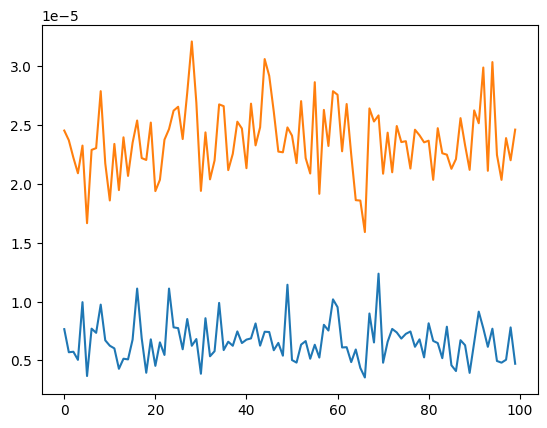

0.001569806656599531 0.002561664220797832
istate: 0
istate: 1
istate: 2
istate: 3


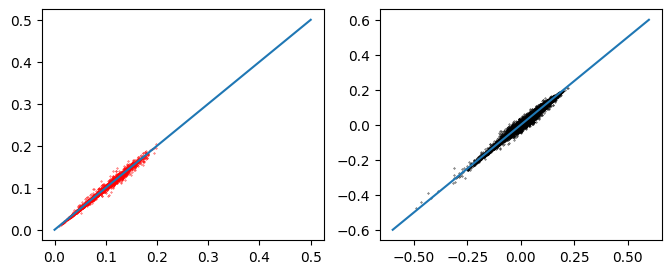

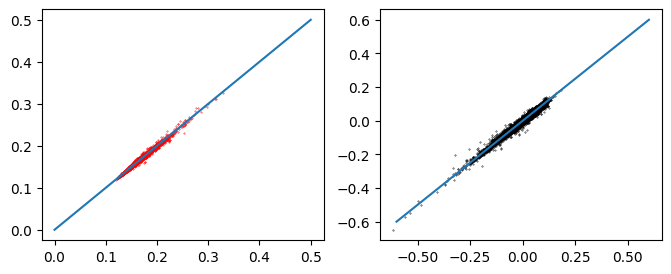

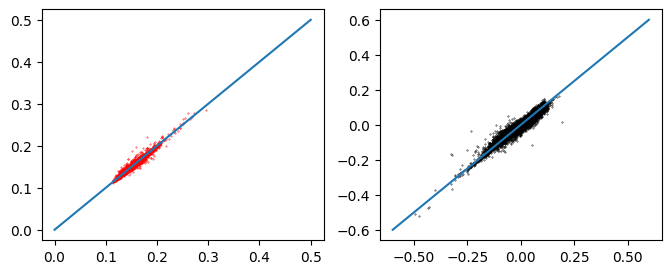

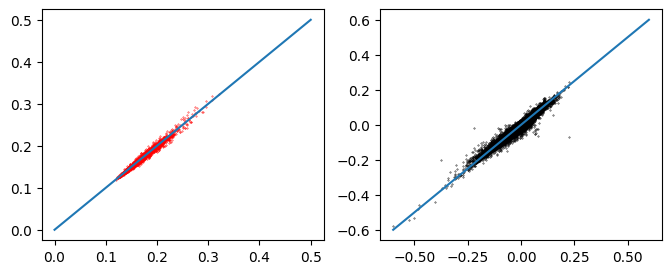

0.0007563827675767243
0.0008345964015461504
0.0010449440451338887
0.0008702166378498077
0.0008019309607334435
0.0006416743854060769
0.0006828490295447409
0.0006993079441599548
0.0006666757399216294
0.0008318938198499382
0.0009704164694994688
0.000811927136965096
0.0007725923205725849
0.0008513180655427277
0.0007834489224478602
0.0007654189830645919
0.0009003396262414753
0.0006053036195226014
0.0007566778222098947
0.0007739468710497022
0.0006901119486428797
0.0009145736694335938
0.0006332762422971427
0.0007511796429753304
0.000773165316786617
0.0006860024877823889
0.0006899078725837171
0.0006720514502376318
0.0007105943514034152
0.000725196732673794
0.0008028321899473667
0.0008126777829602361
0.0005466382135637105


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x2ba2fe64bc10>
Traceback (most recent call last):
  File "/opt/soft/anaconda3/envs/py39/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/opt/soft/anaconda3/envs/py39/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1443, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/opt/soft/anaconda3/envs/py39/lib/python3.9/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/opt/soft/anaconda3/envs/py39/lib/python3.9/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
  File "/opt/soft/anaconda3/envs/py39/lib/python3.9/multiprocessing/connection.py", line 931, in wait
    ready = selector.select(timeout)
  File "/opt/soft/anaconda3/envs/py39/lib/python3.9/selectors.py", line 416, in select
    fd_event_list = self._selector.po

In [32]:

N_epoc = 5000
decay_step = 600
lr0=1e-2
Optimizer = optim.Adam(VQ_S0.parameters(), lr=lr0)
#Optimizer = optim.LBFGS(VQ_S0.parameters(), lr=lr0)
## >>>>>>>> updata >>>>>>>> ##
nowstep = 56500
## >>>>>>>> updata >>>>>>>> ##


pe_start = 0.02
pe_end = 1.0
pf_start = 1000.0
pf_end = 1.0*3*Natoms

lse = np.array([])
lsf = np.array([])

step_rec = np.array([])

for epoch in range(N_epoc):
    
    ####################### @@@@@@@@@@@@@@@@@ ###########################################################
    
    for batch_idx, (x, y, z) in enumerate(train_loader):
        
        for params_ in Optimizer.param_groups:
            if params_['lr'] > 1e-7:
                params_['lr'] = lr0*0.95**(nowstep/decay_step)
            else:
                params_['lr'] = 1e-7
        
        x = x.to(device)
        x.requires_grad = True
        y = y.to(device)
        z = z.to(device)
        
        y_pred, z_pred = VQ_S0(x)        
        loss1 = F.mse_loss(y_pred.type(torch.float32) , y)
        loss2 = F.mse_loss(z_pred.type(torch.float32) , z)
        
        pe = pe_end*(1-(params_['lr']/lr0)) + pe_start*(params_['lr']/lr0)
        pf = pf_end*(1-(params_['lr']/lr0)) + pf_start*(params_['lr']/lr0)
        
        #pe, pf = 1, 3*Natoms
        
        loss = pe*loss1 + pf*loss2
        
        step_rec = np.append(step_rec, nowstep)
        lse = np.append(lse, loss1.item())
        lsf = np.append(lsf, loss2.item())
        
        print(loss.item())
        
        Optimizer.zero_grad()
        loss.backward()
        Optimizer.step()
        
        
        nowstep += 1
        
        
        if nowstep%100==0:
            print(f">>>>>>>> nowstep: {nowstep} @@@@ lr: {params_['lr']} @@@ pe: {pe} @@@ pf:{pf} @@@@ loss: {loss.item()} >>>>>>>>>>")
            print(f">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
            
            plt.plot(lse)
            #plt.ylim(0,1e-3)
            plt.plot(lsf)
            #plt.ylim(0,3e-4)
            
            
            plt.show()
            
            
            
            lse_ = np.array([])
            lsf_ = np.array([])
            y_all = np.array([])
            z_all = np.array([])
            y_pred_all = np.array([])
            z_pred_all = np.array([])
            
            for batch_idx, (x_, y_, z_) in enumerate(test_loader):

        
                x_ = x_.to(device)
                x_.requires_grad = True
                y_ = y_.to(device)
                z_ = z_.to(device)
                
                y_pred_, z_pred_ = VQ_S0(x_) 
                
                loss1_ = torch.abs(y_pred_.type(torch.float32) - y_)
                loss2_ = torch.abs(z_pred_.type(torch.float32) - z_)
                
                y_all = np.append(y_all, y_.cpu().detach().numpy())
                y_pred_all = np.append(y_pred_all, y_pred_.cpu().detach().numpy())
                z_all = np.append(z_all, z_.cpu().detach().numpy())
                z_pred_all = np.append(z_pred_all, z_pred_.cpu().detach().numpy())
        
                lse_ = np.append(lse_, loss1_.cpu().detach().numpy())
                lsf_ = np.append(lsf_, loss2_.cpu().detach().numpy())
                
                
            print(np.mean(lse_), np.mean(lsf_))
            #print
            
            
            for i in range(4):
    
                print(f"istate: {i}")
                plt.figure(figsize=(8,3))
                plt.subplot(121)
                plt.scatter(y_all.reshape(len(list_test),4)[:,i], y_pred_all.reshape(len(list_test),4)[:,i], s=0.1, c='red')
                plt.plot(np.linspace(0,0.5,3), np.linspace(0,0.5,3))
        
                plt.subplot(122)
                plt.scatter(z_all.reshape(len(list_test), 4, Natoms*3)[:,i], z_pred_all.reshape(len(list_test), 4, Natoms*3)[:,i], s=0.1, c='black')
                plt.plot(np.linspace(-0.6,0.6,3), np.linspace(-0.6,0.6,3))
        
            plt.show()


            #torch.save(VQ_S0, './HamKan_ckpt')
            #torch.save(VQ_S0.state_dict(), './HamKan_ckp_params_CKP')

In [247]:
#VQ_S0.state_dict()

In [146]:
#x_test.shape

#x_test
#loss1.dtype
#

In [10]:
#x_test = dataset['train_input'].to(device)

#x_test.requires_grad = True

#y_test = model(x_test)
#dy_test = torch.autograd.grad(y_test, x_test, grad_outputs=torch.ones(y_test.size()).to(device) )[0]


In [16]:
#dy_test
#y_test

#model.parameters